<div style="background:linear-gradient(135deg,#2e1065 0%,#6d28d9 55%,#8b5cf6 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ddd6fe;font-weight:700;text-transform:uppercase">Chapter 43 · Mathematical Statistics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Transformations of Random Variables 🔧</div>
  <div style="font-size:15px;color:#ede9fe;max-width:740px;line-height:1.6">Push a random variable through a function and its distribution changes shape. This notebook works the change-of-variables formula, builds a lognormal from a normal, samples by inverting the CDF, and connects it all to normalizing flows and the reparameterization trick.</div>
  <div style="margin-top:16px;font-size:13px;color:#c4b5fd">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
rng = np.random.default_rng(43)
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
VIOLET="#7c3aed"; PINK="#db2777"; TEAL="#0d9488"
print("ready")

ready


<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 1 · LINEAR TRANSFORMS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Shift and scale</div>
<div style="color:#4a5578;margin-top:6px">The simplest transform is Y = aX + b. It shifts and stretches the distribution: the mean becomes a*mu + b and the standard deviation becomes |a|*sigma. The shape stays the same.</div>
</div>

In [2]:
X = rng.normal(50, 10, size=200_000)
a, b = 2, 5
Y = a*X + b
print(f"X: mean {X.mean():.2f}, sd {X.std():.2f}")
print(f"Y = 2X+5: mean {Y.mean():.2f} (theory {a*50+b}), sd {Y.std():.2f} (theory {abs(a)*10})")

X: mean 49.96, sd 9.97
Y = 2X+5: mean 104.92 (theory 105), sd 19.94 (theory 20)


A linear transform relocates and rescales but does not change the family: a linear function of a normal is still normal. This is exactly the standardization of Chapter 39 run in reverse, and it is why z = (X &minus; mu)/sigma turns any normal into the standard normal.

<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · NONLINEAR TRANSFORMS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A new shape entirely</div>
<div style="color:#4a5578;margin-top:6px">A nonlinear transform can change the shape completely. Exponentiating a normal, Y = exp(X), produces the right-skewed lognormal, the classic model for incomes, stock prices, and city sizes.</div>
</div>

In [3]:
X = rng.normal(0, 0.5, size=200_000)
Y = np.exp(X)              # lognormal
print(f"X is symmetric normal: mean {X.mean():.3f}, skew {stats.skew(X):.3f}")
print(f"Y = exp(X) is right-skewed: mean {Y.mean():.3f}, skew {stats.skew(Y):.3f}")

X is symmetric normal: mean 0.000, skew 0.000
Y = exp(X) is right-skewed: mean 1.134, skew 1.772


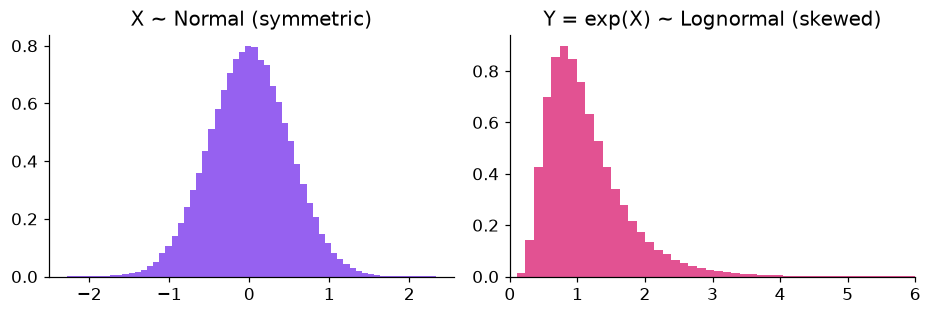

In [4]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(8.6,3))
a1.hist(X,bins=60,density=True,color=VIOLET,alpha=0.8); a1.set_title("X ~ Normal (symmetric)")
a2.hist(Y,bins=80,density=True,color=PINK,alpha=0.8); a2.set_title("Y = exp(X) ~ Lognormal (skewed)"); a2.set_xlim(0,6)
plt.tight_layout(); plt.show()

The symmetric normal becomes a skewed lognormal. Nonlinear transforms reshape distributions, and the **change-of-variables formula** makes this precise: the new density is the old density divided by the magnitude of the transform's derivative, the Jacobian factor.

<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 3 · CHANGE OF VARIABLES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The Jacobian factor</div>
<div style="color:#4a5578;margin-top:6px">For a one-to-one transform Y = g(X), the density transforms as f_Y(y) = f_X(x) / |g'(x)|. The derivative term accounts for how the transform stretches or compresses the axis.</div>
</div>

In [5]:
# verify for Y = exp(X), X ~ N(0,1). The lognormal pdf is the result.
xs = np.linspace(0.05, 6, 300)
analytic = stats.lognorm.pdf(xs, s=1)            # scipy lognormal, sigma=1
# build from the formula: f_Y(y) = f_X(ln y) * |d/dy ln y| = phi(ln y)/y
from_formula = stats.norm.pdf(np.log(xs)) / xs
print(f"max |formula - scipy lognormal| = {np.abs(from_formula-analytic).max():.2e}")

max |formula - scipy lognormal| = 1.11e-16


The hand-built density phi(ln y)/y matches SciPy's lognormal exactly. The 1/y is the Jacobian: it is |d/dy ln(y)|, correcting for the fact that the log compresses large values. Every density transform, however exotic, is this same recipe, old density times the inverse-transform's Jacobian.

<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 4 · INVERSE-TRANSFORM SAMPLING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Turning uniforms into anything</div>
<div style="color:#4a5578;margin-top:6px">A beautiful consequence: if U is uniform on [0,1], then X = F_inverse(U) has CDF F. Feeding uniform numbers through an inverse CDF generates samples from ANY distribution, the engine inside every random sampler.</div>
</div>

In [6]:
U = rng.random(200_000)
# generate exponential(rate=1): inverse CDF is -ln(1-U)
X = -np.log(1 - U)
print(f"inverse-transform sample: mean {X.mean():.3f} (exponential mean 1.0)")
print(f"compare numpy exponential: mean {rng.exponential(1.0, 200_000).mean():.3f}")

inverse-transform sample: mean 0.997 (exponential mean 1.0)
compare numpy exponential: mean 1.000


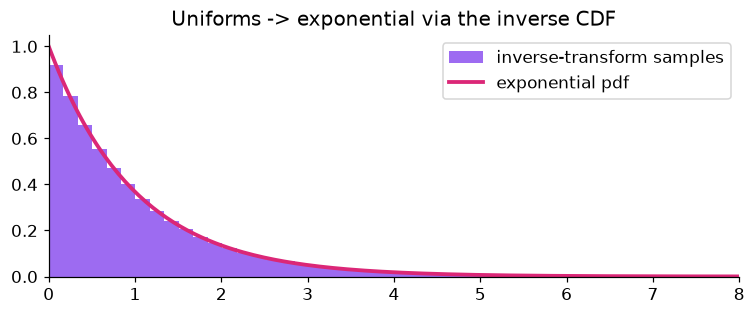

In [7]:
fig,ax=plt.subplots(figsize=(7,3))
ax.hist(X,bins=80,density=True,color=VIOLET,alpha=0.75,label="inverse-transform samples")
xs=np.linspace(0,8,200); ax.plot(xs, np.exp(-xs), color=PINK, lw=2.5, label="exponential pdf")
ax.set_title("Uniforms -> exponential via the inverse CDF"); ax.set_xlim(0,8); ax.legend()
plt.tight_layout(); plt.show()

Plain uniform random numbers, pushed through the inverse CDF F&#8315;&#185;, become exponential samples that match the target density. This **inverse-transform** trick is how computers turn a uniform random generator into samples from any distribution you like.

<div style="background:#f5f3ff;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 5 · TRANSFORMS IN DEEP LEARNING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Flows and the reparameterization trick</div>
<div style="color:#4a5578;margin-top:6px">Transforming distributions is the engine of modern generative models. Normalizing flows chain invertible transforms; the reparameterization trick writes a sample as a transform of a fixed noise source so gradients can flow through it.</div>
</div>

In [8]:
# reparameterization: z = mu + sigma * epsilon, with epsilon ~ N(0,1)
mu, sigma = 3.0, 2.0
eps = rng.normal(0, 1, size=200_000)
z = mu + sigma*eps                 # a sample from N(mu, sigma) as a transform of fixed noise
print(f"reparameterized sample: mean {z.mean():.3f} (target {mu}), sd {z.std():.3f} (target {sigma})")
print("Because z is a DIFFERENTIABLE function of (mu, sigma), gradients can flow through the sampling step.")

reparameterized sample: mean 2.999 (target 3.0), sd 2.004 (target 2.0)
Because z is a DIFFERENTIABLE function of (mu, sigma), gradients can flow through the sampling step.


The **reparameterization trick** writes a random sample z = mu + sigma&middot;epsilon as a *transform* of fixed noise epsilon, so the randomness sits in epsilon and the parameters (mu, sigma) enter through a differentiable function, letting backpropagation train variational autoencoders. **Normalizing flows** stack many invertible transforms (tracking each Jacobian, exactly Demo 3) to morph simple noise into complex data distributions. Change of variables is the mathematics of generative AI.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ What you built</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You transformed variables linearly and nonlinearly, verified the change-of-variables Jacobian formula, generated samples by inverting the CDF, and used the reparameterization trick that powers VAEs. Pushing distributions through functions is how we both model and generate data.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>